In [9]:
%load_ext autoreload    
%autoreload 2
from plot import *
import sys 
sys.path.append('../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:

# results_path = "../../results/gecco-24/sgd-steps"
results_path = "../../results/telo-24-growth"


if not os.path.exists(results_path):
    print(f"Results path {results_path} does not exist")
    raise FileNotFoundError
show=True

os.makedirs(os.path.join(results_path, "plots"), exist_ok=True)

In [17]:
import warnings
from tqdm import trange
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from plot import *

os.makedirs(os.path.join(results_path, "cache"), exist_ok=True)

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

max_batch = None
max_runs = None
max_gen = None

metrics = [
    "replacements_by_batch"
]

file_name = "cached_" + "-".join(metrics)
if max_runs is not None:
    file_name += f"_max_runs_{max_runs}"
if max_batch is not None:
    file_name += f"_max_batch_{max_batch}"
if max_gen is not None:
    file_name += f"_max_gen_{max_gen}"

file_name += ".pkl"
overwrite= True

if os.path.exists(os.path.join(results_path, "cache", file_name)):
    print(f"Loading cached data from {file_name}")
    df = pd.read_pickle(os.path.join(results_path, "cache", file_name))
    print("Loaded")
    overwrite = False
else:
    load_rep = True
    replacements_file = os.path.join(results_path, "cache", file_name.split('.pkl')[0] + "_replacements.pkl")
    if os.path.exists(replacements_file):
        load_rep = False
        with open(replacements_file, "rb") as f:
            replacements = pickle.load(f)
        if len(replacements) == 0:
            load_rep = True

    if load_rep:
        replacements = read_tensor_results(results_path, metrics, max_runs=max_runs, max_batch=max_batch)
        with open(replacements_file, "wb") as f:
            pickle.dump(replacements, f)


    if max_gen is None:
        max_gen = -1
    df = []
    # for cond, run, tensor in replacements:
    #     tensor_np = tensor.numpy()  # Convert tensor to NumPy array
    #     max_gen_above_0 = np.max(np.where(tensor_np > 0))
    #     tensor_np = tensor_np[:,:,:max_gen_above_0]
    #     tensor_np = tensor_np[:,:,:max_gen]
        
        
    #     from_cells, to_cells, generations = tensor_np.shape
    #     for from_cell in trange(from_cells):
    #         for to_cell in range(to_cells):
    #             for generation in range(generations):
    #                 df.append({
    #                     'condition': cond,
    #                     'run': run,
    #                     'from_cell': from_cell,
    #                     'to_cell': to_cell,
    #                     'generation': generation,
    #                     'replace': tensor_np[from_cell, to_cell, generation]
    #                 })
    # or, via chunking
    chunk_size = 2
    c = 0
    chunks = [replacements[i:i + chunk_size] for i in range(0, len(replacements), chunk_size)]
    # after each chunk, we save to disk
    for chunk in chunks:
        df = []

        for i, (cond, run, tensor) in enumerate(chunk):
            tensor_np = tensor.numpy()  # Convert tensor to NumPy array
            max_gen_above_0 = np.max(np.where(tensor_np > 0))
            tensor_np = tensor_np[:,:,:max_gen_above_0]
            tensor_np = tensor_np[:,:,:max_gen]
            
            
            from_cells, to_cells, generations = tensor_np.shape
            for from_cell in trange(from_cells):
                for to_cell in range(to_cells):
                    for generation in range(generations):
                        df.append({
                            'condition': cond,
                            'run': run,
                            'from_cell': from_cell,
                            'to_cell': to_cell,
                            'generation': generation,
                            'replace': tensor_np[from_cell, to_cell, generation]
                        })
        df = pd.DataFrame(df)
        df.to_pickle(os.path.join(results_path, "cache", file_name.split('.pkl')[0] + f"_chunk_{c}.pkl"))
        print(f"Saved chunk {c} to disk")
        c += 1

        del chunk
                





Loading: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s]

Error processing replacements_by_batch
index 76 is out of bounds for dimension 0 with size 50
Traceback (most recent call last):
  File "/gpfs2/scratch/jsdean/move/public_github/analysis/plot.py", line 168, in read_tensor_results
    t = t[(t.sum(dim=0).sum(dim=0) != 0).nonzero().squeeze()]
IndexError: index 76 is out of bounds for dimension 0 with size 50

No results found


In [12]:
# load all chunks
overwrite = False
if overwrite:
    df = pd.DataFrame(df)
    for file in os.listdir(os.path.join(results_path, "cache")):
        if 'chunk' in file:
            loaded_df = pd.read_pickle(os.path.join(results_path, "cache", file))
            loaded_df = loaded_df[loaded_df['replace'] > 0]
            df = pd.concat([df, loaded_df])
            del loaded_df

    df.to_pickle(os.path.join(results_path, "cache", file_name))
df

[]

In [13]:
# plot generation by index hue condition
sns.lineplot(data=df, x=df.index, y='generation', hue='condition')
plt.show()

ValueError: Could not interpret value `generation` for parameter `y`

In [ ]:
df['condition'].unique()

array(['original-move-0-steps-0-features', '000_steps_', '1000_steps_',
       '100_steps_', '016_steps_'], dtype=object)

In [ ]:
# display 100 rows
pd.set_option('display.max_rows', 100)
df[df['run']=='run_12115530784058315246'].head(100)


,condition,run,from_cell,to_cell,generation,replace
6004,016_steps_,run_12115530784058315246,0,1,1,1.0
12007,016_steps_,run_12115530784058315246,0,2,1,1.0
14970,016_steps_,run_12115530784058315246,0,2,2964,1.0
15073,016_steps_,run_12115530784058315246,0,2,3067,1.0
18419,016_steps_,run_12115530784058315246,0,3,410,1.0
18905,016_steps_,run_12115530784058315246,0,3,896,1.0
24013,016_steps_,run_12115530784058315246,0,4,1,1.0
36019,016_steps_,run_12115530784058315246,0,6,1,1.0
42022,016_steps_,run_12115530784058315246,0,7,1,1.0
48025,016_steps_,run_12115530784058315246,0,8,1,1.0


In [ ]:
df[df['condition']=='016_steps_']['run'].unique()

array(['run_12115530784058315246', 'run_3179147697411592686',
       'run_5021508158519448046', 'run_5268746473425867246',
       'run_13188078710231601646', 'run_930153940478267886',
       'run_7119415952493187566', 'run_6330708396144464366',
       'run_9616189825877348846', 'run_16714616029847949806',
       'run_12587644644465775086', 'run_9083261195638608366',
       'run_377658504382779886', 'run_14615341929477968366',
       'run_428442438228447726', 'run_7126569272073982446',
       'run_3214857223745114606', 'run_13817264635670106606'],
      dtype=object)

In [ ]:
# os.makedirs(os.path.join(results_path, "cache"), exist_ok=True)

# df.to_pickle(os.path.join(results_path, "cache", file_name))

In [ ]:
def plot_run_heatmap(df, condition, run, title='Replacements'):
    df_run = df[df['condition'] == condition]
    df_run = df_run[df_run['run'] == run]

    # Pivot the DataFrame to get a 2D matrix for the heatmap
    # Here, we are averaging the replacements over all generations for each from-to cell pair
    heatmap_data = df_run.groupby(['from_cell', 'to_cell'])['replace'].sum().unstack()
    # account for the fact that we didn't include 0's... ie the mean should be over all generations x cells x cells
    # heatmap_data = heatmap_data/(df_run['generation'].max()*df_run['from_cell'].max()*df_run['to_cell'].max())
    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap='viridis')
    plt.title(title)
    plt.xlabel('To Cell')
    plt.ylabel('From Cell')
    plt.show()


original-move-0-steps-0-features


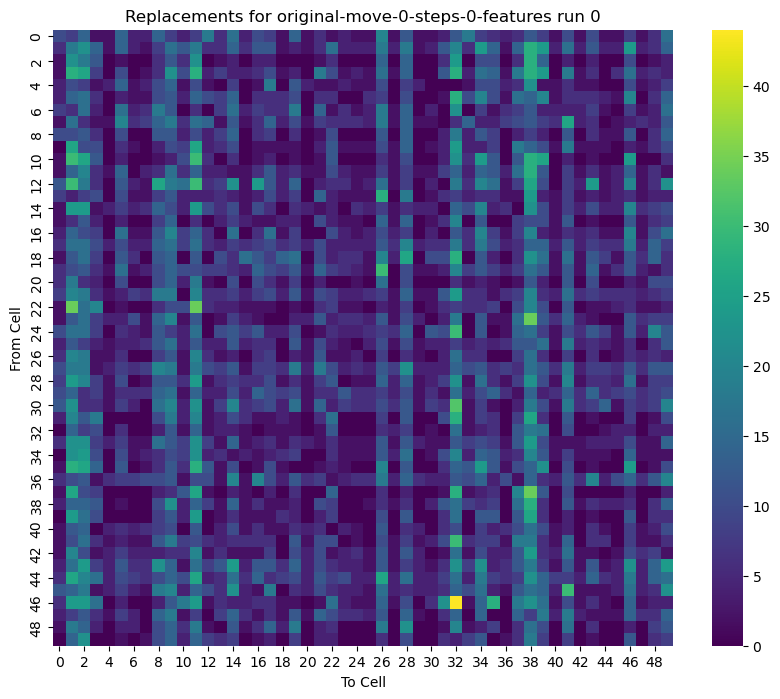

000_steps_


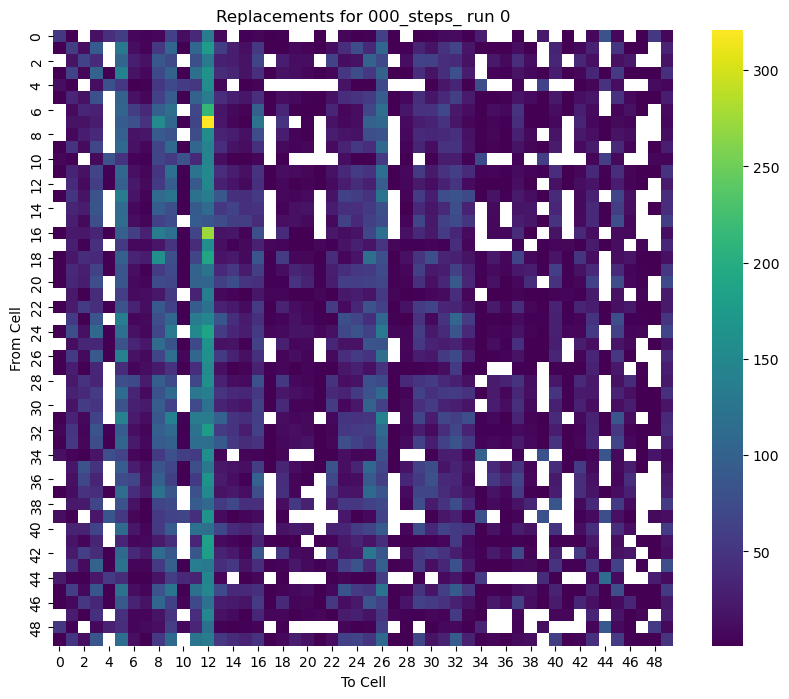

1000_steps_


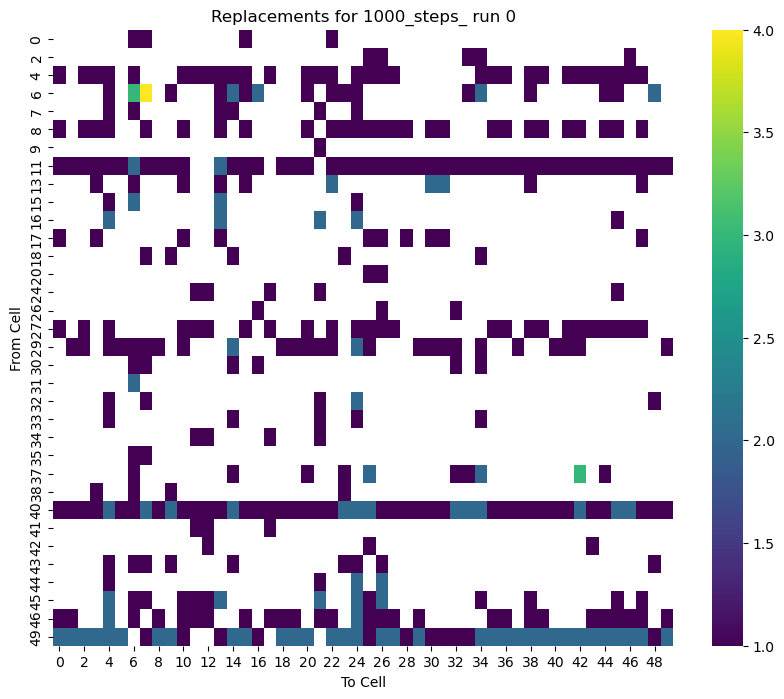

100_steps_


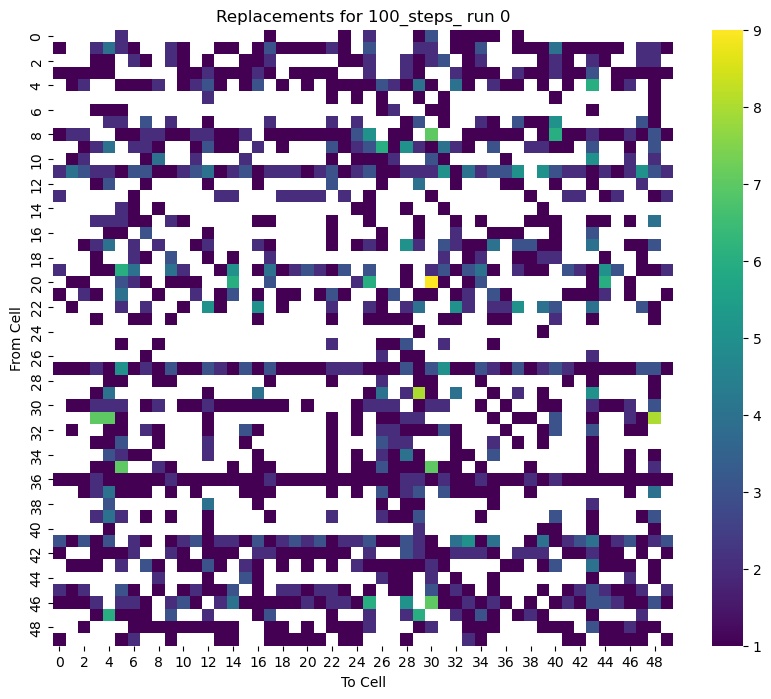

016_steps_


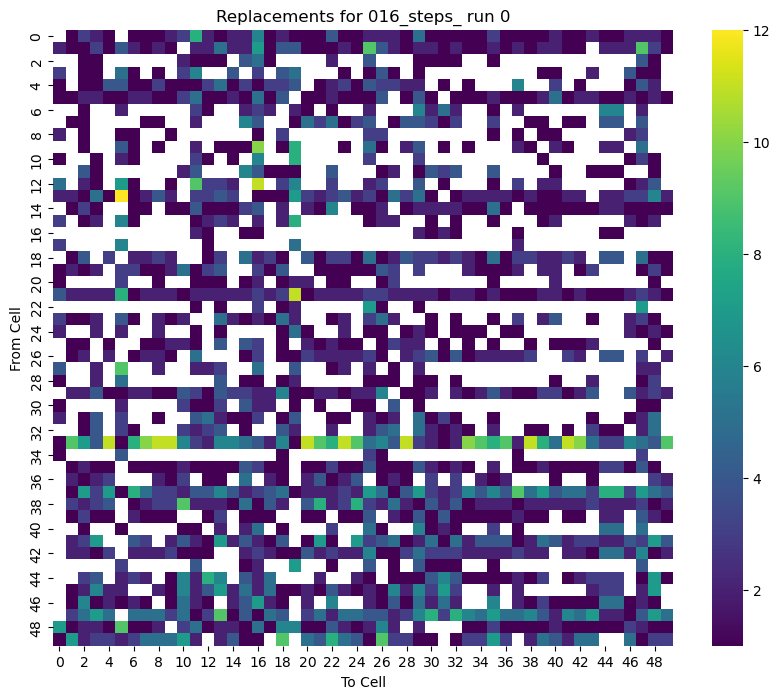

In [ ]:
# plot a heatmap for the first default run
for condition in df['condition'].unique():
    print(condition)
    plot_run_heatmap(df, condition, df[df['condition']==condition]['run'].unique()[0], title=f"Replacements for {condition} run 0")


../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_18401199831074804206
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_1220579775122379246
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17422034561322258926
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17431451749565141486
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_1227784410962727406
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17427382353951527406
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17428098582697808366
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17429881981968126446
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17425881649428632046
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17392741638823023086
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17430893489716007406
../../results/gecco-24/sgd-steps/conditions/
000_steps_ run_17422806839391752686
../../results/gecco-24/sgd-ste

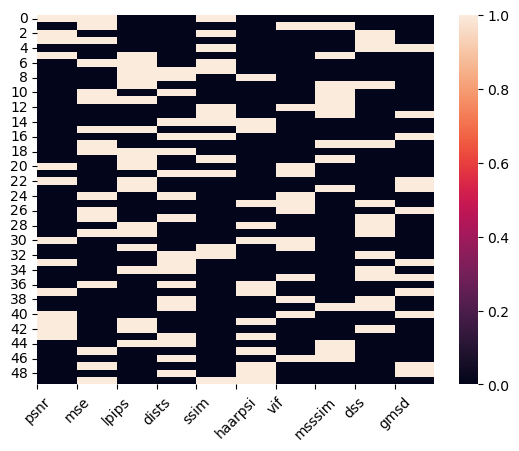

In [ ]:
# load masks

# iterate conditions and runs
masks = {}
fns_names = {}

for cond, run, data in replacements:
    print(os.path.join(results_path, f"conditions/"))
    if not os.path.exists( os.path.join(results_path, f"conditions/{cond}/{run}/Fm_mask.pt")):
        continue
    print(cond, run)
    mask_path = os.path.join(results_path, f"conditions/{cond}/{run}/Fm_mask.pt")
    mask = torch.load(mask_path, map_location='cpu')
    masks[(cond, run)] = mask.cpu()
    if not os.path.exists(os.path.join(results_path, f"conditions/{cond}/{run}/function_names.csv")):
        continue
    with open(os.path.join(results_path, f"conditions/{cond}/{run}/function_names.csv"), 'r') as f:
        fns = f.read().split(",")
        fns_names[(cond, run)] = fns
    

sns.heatmap(masks[list(masks.keys())[0]].T)
plt.xticks(ticks=np.arange(0, len(fns_names[list(masks.keys())[-1]]), step=1), labels=fns_names[list(masks.keys())[-1]], rotation=45)
plt.show()

                          condition    replace
0                        000_steps_  1672424.0
1                        016_steps_    84703.0
2                       1000_steps_    26881.0
3                        100_steps_    79660.0
4  original-move-0-steps-0-features   555254.0


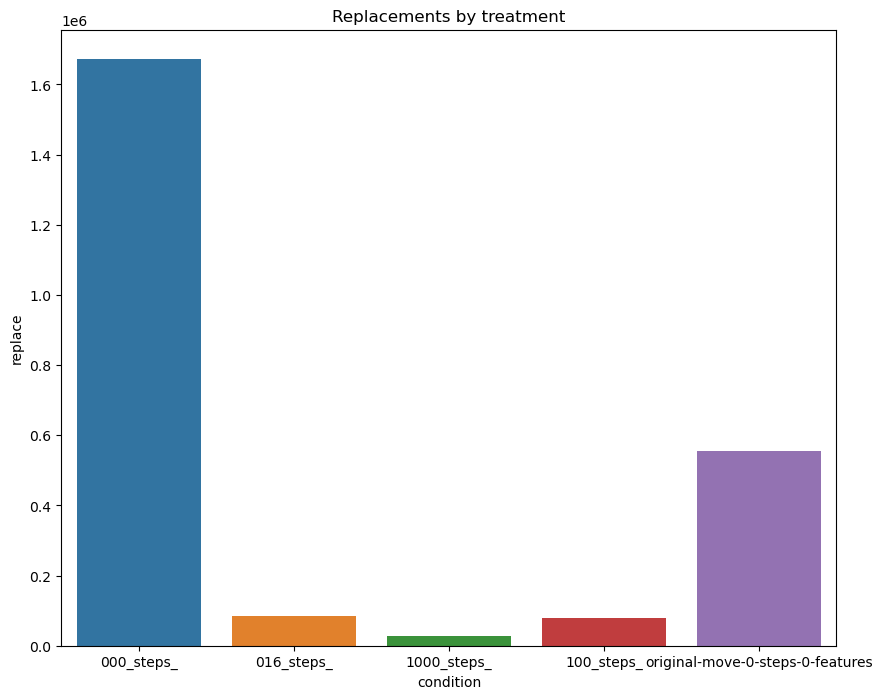

In [ ]:
# plot sum of replaces
def plot_replace_sum(df, title='Replacements by treatment'):
    plot_data = df.groupby('condition')['replace'].sum().reset_index()
    print(plot_data)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=plot_data, x='condition', y='replace')
    plt.title(title)
    plt.show()


plot_replace_sum(df, title='Replacements by treatment')


In [ ]:
def euc_distance(a, b):
    return np.linalg.norm(a.astype(float) - b.astype(float))

def euc_distance_of_jump(jump):
    return euc_distance(jump[0], jump[1])

def euc_distance_of_replacements(df):
    # df_filtered = df[(df['run'] == run) & (df['condition'] == condition)]
    # if not (condition, run) in masks:
        # return 0.0, {}
    for condition, run in masks.keys():
        mask = masks[(condition, run)].cpu().numpy()

        # Extract relevant columns
        # from_cells = df_filtered['from cell'].values
        # to_cells = df_filtered['to cell'].values
        generations = df['generation'].values
        replacements = df['replace'].values

        print(replacements.shape)
        print(mask.shape)

        n_cells = mask.shape[-1]
        n_gens = df['generation'].max() + 1
        # Reshape the replacements array to match the mask's shape
        # replacements_reshaped = replacements.reshape((n_cells, n_cells, n_gens))

        mean_dist = np.mean([euc_distance(mask[:, i], mask[:, j]) for i in range(n_cells) for j in range(n_cells)])

        dist_lookup = {}
        for i in range(n_cells):
            for j in range(n_cells):
                dist_lookup[(i, j)] = euc_distance(mask[:, i], mask[:, j])
                
        df['euc_dist'] = df.apply(lambda x: x['replace']*dist_lookup[(x['from_cell'], x['to_cell'])], axis=1)
    return mean_dist, dist_lookup

if os.path.exists(os.path.join(results_path, "replacements_euc_dist_df.pkl")):
    df = pd.read_pickle(os.path.join(results_path, "replacements_euc_dist_df.pkl"))
else:
    mean_dist, dist_lookup = euc_distance_of_replacements(df)
    df.to_pickle(os.path.join(results_path, "replacements_euc_dist_df.pkl"))

    # cache the results


    
    

In [ ]:
# load the distances
assert os.path.exists(os.path.join(results_path, "replacements_euc_dist_df.pkl"))
euc_df = pd.read_pickle(os.path.join(results_path, "replacements_euc_dist_df.pkl"))
euc_df.tail(100)

,condition,run,from_cell,to_cell,generation,replace,euc_dist
29325037,016_steps_,run_13817264635670106606,49,5,177,1.0,2.000000
29325145,016_steps_,run_13817264635670106606,49,5,285,1.0,2.000000
29326846,016_steps_,run_13817264635670106606,49,5,1986,1.0,2.000000
29326996,016_steps_,run_13817264635670106606,49,5,2136,1.0,2.000000
29327409,016_steps_,run_13817264635670106606,49,5,2549,1.0,2.000000
29329495,016_steps_,run_13817264635670106606,49,5,4635,1.0,2.000000
29331037,016_steps_,run_13817264635670106606,49,6,285,1.0,2.000000
29336647,016_steps_,run_13817264635670106606,49,7,3,1.0,2.000000
29342539,016_steps_,run_13817264635670106606,49,8,3,1.0,2.000000
29342821,016_steps_,run_13817264635670106606,49,8,285,1.0,2.000000


In [ ]:

# plot dists
def plot_euc_distance_map(euc_df, condition, run):
    dists = euc_df[(euc_df['condition'] == condition) & (euc_df['run'] == run)]
    # average over from-to cell pairs
    dists = dists.groupby(['from_cell', 'to_cell'])['euc_dist'].mean().reset_index()
    # Convert dictionary to DataFrame
    # Pivot the DataFrame to create a matrix
    heatmap_data = dists.pivot(index='from_cell', columns='to_cell', values='euc_dist')

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap='viridis')
    plt.title(f'Euclidean distance heatmap')
    plt.xlabel('To Cell')
    plt.ylabel('From Cell')
    plt.show()
    
def plot_euc_distance_time(dists):
    # plot a lineplot of the average distance over time
    plt.figure(figsize=(10, 8))
    
    this_dists =  dists.copy()
    # drop nan
    this_dists = this_dists.dropna()
    
    
    this_dists = this_dists.reset_index()
    
    sns.lineplot(data=this_dists, x='generation', y='euc_dist', hue='condition')
    plt.title(f'Average Euclidean distance over time')
    plt.xlabel('Generation')
    plt.ylabel('Distance')
    plt.show()
    



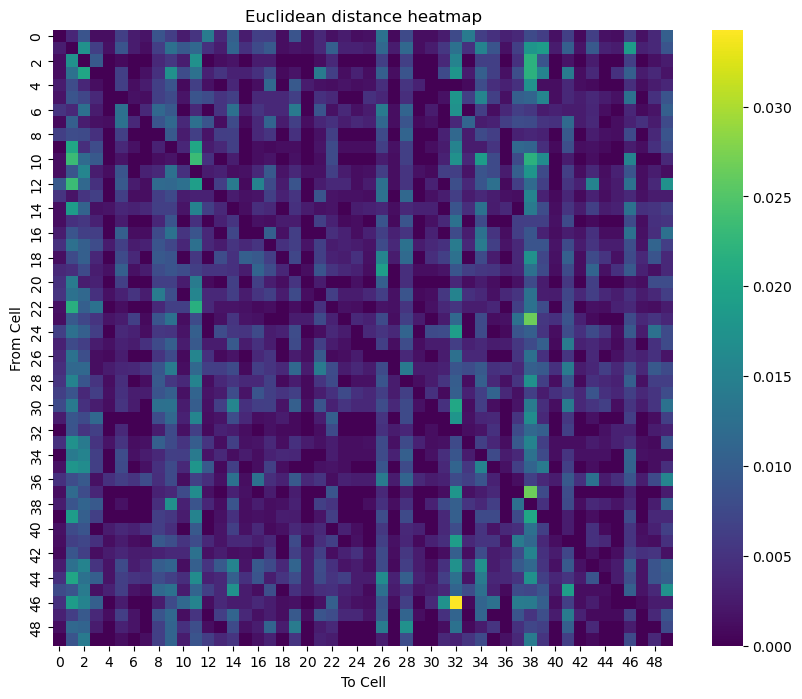

In [ ]:
plot_euc_distance_map(euc_df, euc_df['condition'].unique()[0], euc_df['run'].unique()[0])

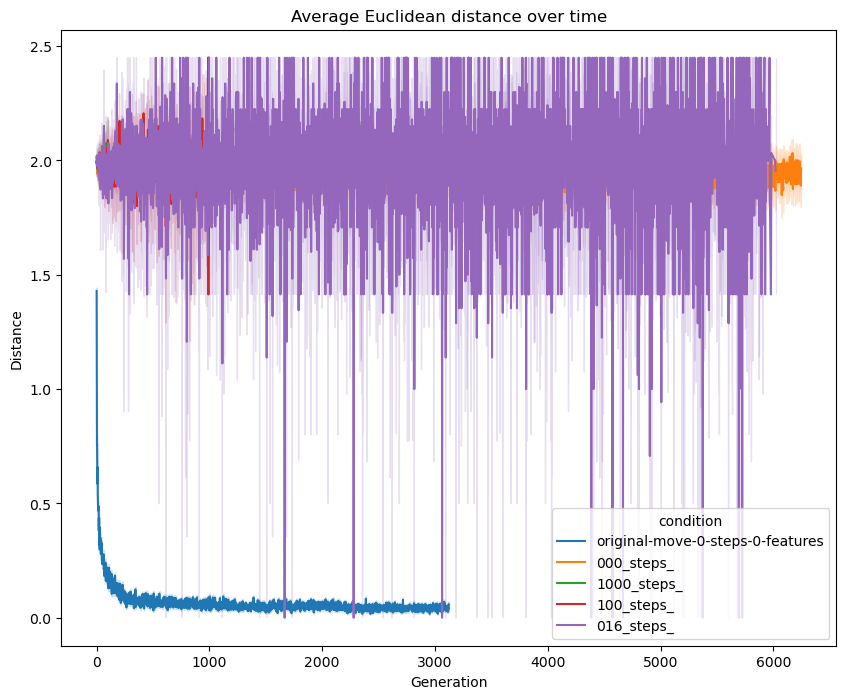

In [ ]:
plot_euc_distance_time(euc_df)


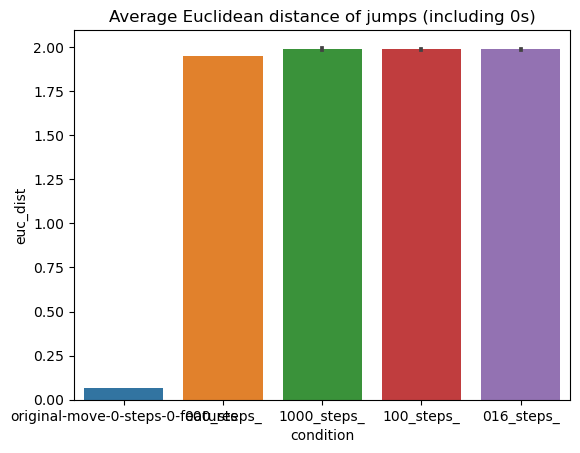

In [ ]:
# compare average jump euc distance
# get the average jump distance for each run

# avg_jump_dists = all_jump_dists.groupby(['condition', 'run']).mean().reset_index()

sns.barplot(data=euc_df, x='condition', y='euc_dist')
plt.title("Average Euclidean distance of jumps (including 0s)")

plt.show()

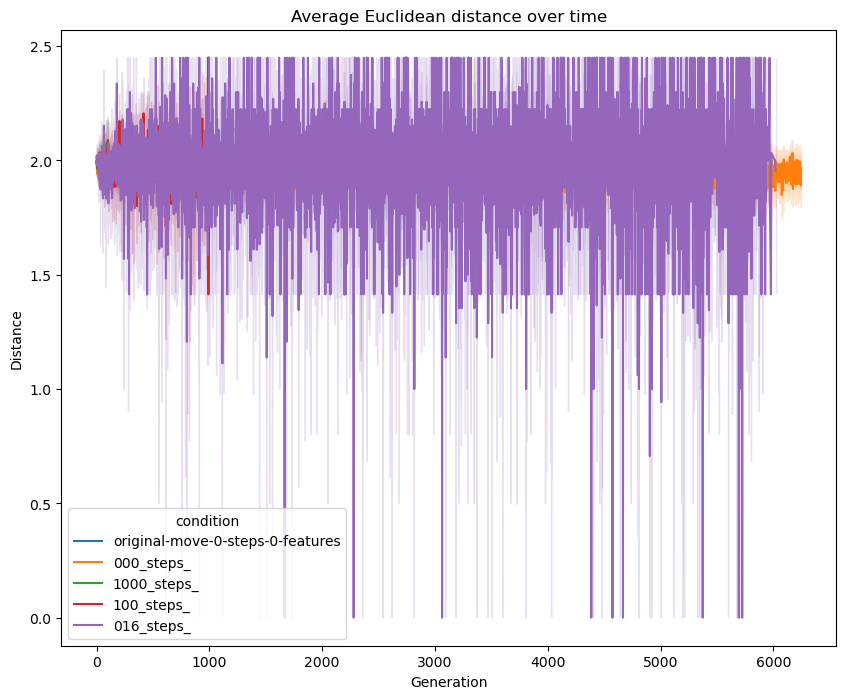

In [ ]:

# exclude 0s
plot_euc_distance_time(euc_df[euc_df['replace'] > 0])

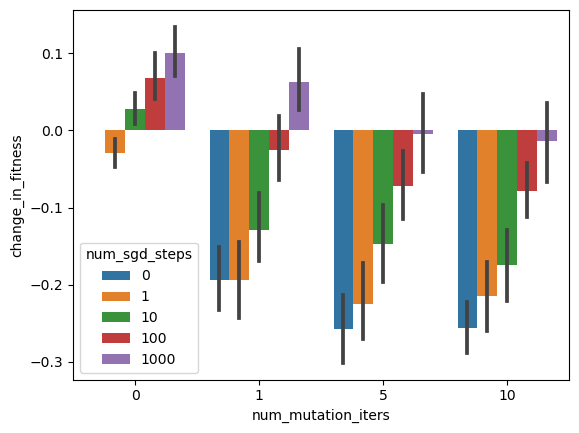

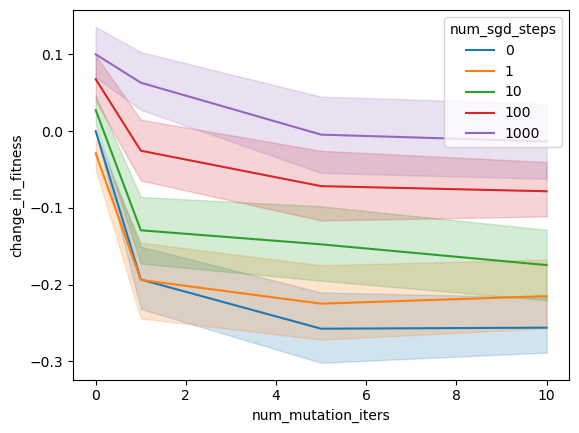

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./n_mutations_by_sgd.csv")


sns.barplot(data=df, x="num_mutation_iters", y="change_in_fitness", hue="num_sgd_steps")
plt.savefig("./n_mutations_by_sgd.png")
plt.show()

#as line
sns.lineplot(data=df, x="num_mutation_iters", y="change_in_fitness", hue="num_sgd_steps", palette="tab10")
plt.savefig("./n_mutations_by_sgd_line.png")
plt.show()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'MOVE-SGD-Grow-And-Prune-No-Min-500-steps'),
  Text(1, 0, 'MOVE-SGD-Start-Small-No-Grow-500-steps'),
  Text(2, 0, 'MOVE-SGD-Start-Big-No-Grow-0-steps'),
  Text(3, 0, 'MOVE-SGD-Fast-Grow-0-steps'),
  Text(4, 0, 'MOVE-SGD-Slow-Growth-500-steps'),
  Text(5, 0, 'MOVE-SGD-Grow-And-Prune-500-steps'),
  Text(6, 0, 'MOVE-SGD-Fast-Grow-500-steps'),
  Text(7, 0, 'MOVE-SGD-Grow-And-Prune-0-steps'),
  Text(8, 0, 'MOVE-SGD-Grow-And-Prune-No-Min-0-steps'),
  Text(9, 0, 'MOVE-SGD-Start-Small-No-Grow-0-steps'),
  Text(10, 0, 'MOVE-SGD-Start-Big-No-Grow-500-steps'),
  Text(11, 0, 'MOVE-SGD-Grow-And-Prune-Less-500-steps'),
  Text(12, 0, 'MOVE-SGD-Grow-And-Prune-Less-0-steps')])

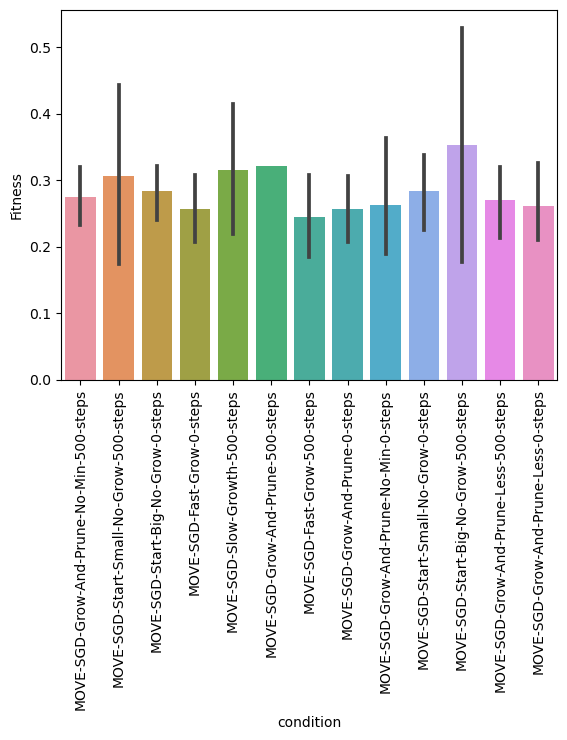

In [ ]:
# do the same with analysis/partial_fitness.csv
df = pd.read_csv("partial_fitness.csv")
sns.barplot(data=df, x="condition", y="genome_start_fitness")
plt.ylabel("Fitness")
plt.savefig("partial_fitness.png")
# labels rotated
plt.xticks(rotation=90)